Tras el benchmark previo, se restringe la selección final al conjunto de variables reduced, ya que fue el que mostró mejor comportamiento global.
Además, OCSVM se descarta por su elevado coste computacional, Isolation Forest por su bajo rendimiento, y MLP se mantiene solo como referencia supervisada.

Por tanto, la selección final del detector no supervisado se realiza entre AE reduced y LOF reduced.

## Imports

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.neighbors import LocalOutlierFactor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

pd.set_option("display.max_columns", None)

## Carga de datos

**Objetivo**

En este notebook se realiza la selección final del detector de anomalías para el pipeline AIS.

Tras el benchmark previo:
- el conjunto de variables `reduced` mostró el mejor equilibrio entre rendimiento y simplicidad,
- Isolation Forest se descartó por bajo rendimiento,
- One-Class SVM se descartó por su alto coste computacional,
- MLP se conserva solo como referencia supervisada.

Por tanto, la selección final del modelo no supervisado se realiza entre:
- **Autoencoder (AE)**
- **Local Outlier Factor (LOF)**

Además de comparar ambos modelos, este notebook:
1. reentrena los finalistas,
2. evalúa su rendimiento en holdout,
3. selecciona el modelo principal,
4. guarda scores y predicciones para las siguientes fases del pipeline.

In [2]:
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/TFG/"
data_path = base_path + "data_processed/"
results_path = base_path + "results/benchmark/"
model_selection_path = base_path + "results/model_selection/"

os.makedirs(model_selection_path, exist_ok=True)

train_df = pd.read_csv(data_path + "train_clean.csv")
test_df = pd.read_csv(data_path + "test_augmented.csv")
benchmark_results_df = pd.read_csv(results_path + "benchmark_results.csv")

feature_cols = joblib.load(data_path + "feature_cols.pkl")
base_features = joblib.load(data_path + "base_features.pkl")
derived_features = joblib.load(data_path + "derived_features.pkl")
domain_features = joblib.load(data_path + "domain_features.pkl")

Mounted at /content/drive


A partir del benchmark previo, la selección fina del modelo se restringe al conjunto de variables reduced, ya que fue el que mostró el mejor comportamiento global entre rendimiento y simplicidad.

In [3]:
features_reduced = [
    "speed_mean",
    "delta_course_mean",
    "turning_rate_mean",
    "distance_km",
    "duration",
    "ais_gap",
    "slow_motion",
    "high_speed_flag",
    "low_distance_flag"
]

features_reduced

['speed_mean',
 'delta_course_mean',
 'turning_rate_mean',
 'distance_km',
 'duration',
 'ais_gap',
 'slow_motion',
 'high_speed_flag',
 'low_distance_flag']

## Preparación de holdout


El conjunto `test_augmented` se divide para reservar una partición de evaluación final (`holdout`).
En este notebook se utilizará el holdout para la comparación final entre AE y LOF.

In [4]:
validation_df, holdout_df = train_test_split(
    test_df,
    test_size=0.5,
    random_state=42,
    stratify=test_df["anomaly_type"]
)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Holdout:", holdout_df.shape)

Train: (1228043, 37)
Validation: (156389, 39)
Holdout: (156389, 39)


In [5]:
benchmark_results_df.groupby("model")[["precision", "recall", "f1", "time_sec"]].mean().sort_values("f1", ascending=False)

,precision,recall,f1,time_sec
model,,,,
MLP,0.993232,0.442185,0.611936,20.801086
OCSVM,0.392764,0.526215,0.449800,17893.325712
LOF,0.357012,0.558927,0.435714,987.833742
AE,0.430691,0.380565,0.404079,167.265067
IF,0.088606,0.093446,0.090958,8.763212


In [6]:
benchmark_results_df.sort_values("f1", ascending=False).head(10)

,model,feature_set,n_features,precision,recall,f1,time_sec,config_json,contamination,n_estimators,n_neighbors,nu,kernel,gamma,epochs,batch_size,threshold_percentile,threshold
0,MLP,reduced,9,0.993232,0.442185,0.611936,20.801086,"{""model"": ""MLP"", ""feature_set"": ""reduced"", ""ep...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,NaN,0.5
1,AE,reduced,9,0.525703,0.464520,0.493221,164.613829,"{""model"": ""AE"", ""feature_set"": ""reduced"", ""epo...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,95.0,NaN
2,LOF,reduced,9,0.370870,0.580904,0.452712,394.063941,"{""model"": ""LOF"", ""feature_set"": ""reduced"", ""co...",0.06,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OCSVM,reduced,9,0.392764,0.526215,0.449800,17893.325712,"{""model"": ""OCSVM"", ""feature_set"": ""reduced"", ""...",NaN,NaN,NaN,0.05,rbf,scale,NaN,NaN,NaN,NaN
4,LOF,base_only,13,0.343154,0.536949,0.418715,1581.603543,"{""model"": ""LOF"", ""feature_set"": ""base_only"", ""...",0.06,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AE,base_only,13,0.335678,0.296610,0.314937,169.916305,"{""model"": ""AE"", ""feature_set"": ""base_only"", ""e...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,95.0,NaN
6,IF,reduced,9,0.109598,0.117288,0.113313,8.704440,"{""model"": ""IF"", ""feature_set"": ""reduced"", ""con...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,IF,base_only,13,0.080757,0.084407,0.082541,8.289271,"{""model"": ""IF"", ""feature_set"": ""base_only"", ""c...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,IF,full,27,0.075464,0.078644,0.077021,9.295924,"{""model"": ""IF"", ""feature_set"": ""full"", ""contam...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
reference_supervised = benchmark_results_df[
    (benchmark_results_df["model"] == "MLP") &
    (benchmark_results_df["feature_set"] == "reduced")
].copy()

unsupervised_finalists = benchmark_results_df[
    (benchmark_results_df["model"].isin(["AE", "LOF"])) &
    (benchmark_results_df["feature_set"] == "reduced")
].sort_values("f1", ascending=False).copy()

discarded_models = benchmark_results_df[
    (
        ((benchmark_results_df["model"] == "OCSVM") & (benchmark_results_df["feature_set"] == "reduced")) |
        ((benchmark_results_df["model"] == "IF") & (benchmark_results_df["feature_set"] == "reduced"))
    )
].sort_values("f1", ascending=False).copy()

print("Baseline supervisado:")
display(reference_supervised)

print("Finalistas no supervisados:")
display(unsupervised_finalists)

print("Modelos descartados:")
display(discarded_models)

Baseline supervisado:


,model,feature_set,n_features,precision,recall,f1,time_sec,config_json,contamination,n_estimators,n_neighbors,nu,kernel,gamma,epochs,batch_size,threshold_percentile,threshold
0,MLP,reduced,9,0.993232,0.442185,0.611936,20.801086,"{""model"": ""MLP"", ""feature_set"": ""reduced"", ""ep...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,NaN,0.5


Finalistas no supervisados:


,model,feature_set,n_features,precision,recall,f1,time_sec,config_json,contamination,n_estimators,n_neighbors,nu,kernel,gamma,epochs,batch_size,threshold_percentile,threshold
1,AE,reduced,9,0.525703,0.464520,0.493221,164.613829,"{""model"": ""AE"", ""feature_set"": ""reduced"", ""epo...",NaN,NaN,NaN,NaN,NaN,NaN,12.0,256.0,95.0,NaN
2,LOF,reduced,9,0.370870,0.580904,0.452712,394.063941,"{""model"": ""LOF"", ""feature_set"": ""reduced"", ""co...",0.06,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Modelos descartados:


,model,feature_set,n_features,precision,recall,f1,time_sec,config_json,contamination,n_estimators,n_neighbors,nu,kernel,gamma,epochs,batch_size,threshold_percentile,threshold
3,OCSVM,reduced,9,0.392764,0.526215,0.449800,17893.325712,"{""model"": ""OCSVM"", ""feature_set"": ""reduced"", ""...",NaN,NaN,NaN,0.05,rbf,scale,NaN,NaN,NaN,NaN
6,IF,reduced,9,0.109598,0.117288,0.113313,8.704440,"{""model"": ""IF"", ""feature_set"": ""reduced"", ""con...",0.06,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


A partir del benchmark:
- **MLP reduced** se conserva solo como referencia supervisada.
- **AE reduced** se mantiene como principal candidato no supervisado por su mejor equilibrio entre precision y recall.
- **LOF reduced** se mantiene como segundo finalista por su mayor sensibilidad.
- **OCSVM reduced** se descarta por su coste computacional.
- **IF reduced** se descarta por bajo rendimiento.

Por tanto, la comparación final se realiza únicamente entre **AE reduced** y **LOF reduced**.

Escalado

In [8]:
def prepare_scaled_data(train_df, test_df, features):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features])
    X_test = scaler.transform(test_df[features])
    return X_train, X_test, scaler

## Auto Encoder

In [9]:
def fit_autoencoder(X_train, input_dim, epochs=20, batch_size=256):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(16, activation="relu"),
        Dense(input_dim, activation="linear")
    ])

    model.compile(optimizer="adam", loss="mse")

    history = model.fit(
        X_train,
        X_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    return model, history

In [18]:
def evaluate_ae_base(train_df, holdout_df, features, epochs=20, batch_size=256, threshold_percentile=95):
    X_train_scaled, X_holdout_scaled, scaler = prepare_scaled_data(train_df, holdout_df, features)

    ae_model, history = fit_autoencoder(
        X_train_scaled,
        input_dim=X_train_scaled.shape[1],
        epochs=epochs,
        batch_size=batch_size
    )

    X_train_pred = ae_model.predict(X_train_scaled, verbose=0)
    train_errors = np.mean((X_train_scaled - X_train_pred) ** 2, axis=1)

    threshold = np.percentile(train_errors, threshold_percentile)

    X_holdout_pred = ae_model.predict(X_holdout_scaled, verbose=0)
    holdout_errors = np.mean((X_holdout_scaled - X_holdout_pred) ** 2, axis=1)

    y_true = holdout_df["is_synthetic"].values
    y_pred = (holdout_errors > threshold).astype(int)

    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold
    }

    return {
        "model": ae_model,
        "history": history,
        "scaler": scaler,
        "scores": holdout_errors,
        "preds": y_pred,
        "metrics": metrics,
        "train_errors": train_errors
    }

In [19]:
ae_result = evaluate_ae_base(
    train_df=train_df,
    holdout_df=holdout_df,
    features=features_reduced,
    epochs=12,
    batch_size=256,
    threshold_percentile=95
)

ae_result["metrics"]

{'precision': 0.3701079622132254,
 'recall': 0.495819209039548,
 'f1': 0.42383850091760844,
 'threshold': np.float64(0.0004574015276019936)}

## Local Outlier Factor (LOF)

In [12]:
def evaluate_lof(train_df, holdout_df, features, n_neighbors=35, contamination=0.03):
    X_train_scaled, X_holdout_scaled, scaler = prepare_scaled_data(train_df, holdout_df, features)

    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=True
    )
    lof.fit(X_train_scaled)

    lof_raw = lof.decision_function(X_holdout_scaled)
    lof_scores = -lof_raw
    y_pred = (lof.predict(X_holdout_scaled) == -1).astype(int)

    y_true = holdout_df["is_synthetic"].values

    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

    return {
        "model": lof,
        "scaler": scaler,
        "scores": lof_scores,
        "preds": y_pred,
        "metrics": metrics
    }

In [14]:
lof_result = evaluate_lof(
    train_df=train_df,
    holdout_df=holdout_df,
    features=features_reduced,
    n_neighbors= 20,
    contamination= 0.06
  )

lof_result["metrics"]

{'precision': 0.3709400486478752,
 'recall': 0.5858757062146893,
 'f1': 0.454266690029788}

## Comparación

In [21]:
comparison_df = pd.DataFrame([
    {
        "model": "AE_base",
        "feature_set": "reduced",
        **ae_result["metrics"]
    },
    {
        "model": "LOF",
        "feature_set": "reduced",
        **lof_result["metrics"]
    }
]).sort_values("f1", ascending=False).reset_index(drop=True)

comparison_df

,model,feature_set,precision,recall,f1,threshold
0,LOF,reduced,0.370940,0.585876,0.454267,NaN
1,AE_base,reduced,0.370108,0.495819,0.423839,0.000457


## Reentrenamiento

Los hiperparámetros utilizados para AE y LOF se fijan a partir de los mejores resultados obtenidos en el benchmark previo, garantizando coherencia entre fases y evitando reoptimización en el conjunto de validación.

### Selección del umbral en validación

Antes de evaluar el Autoencoder en holdout, se selecciona el umbral de decisión en el conjunto de validación. En lugar de fijarlo de forma arbitraria, se explora un rango de percentiles del error de reconstrucción y se compara su efecto sobre precision, recall y F1.

Dado el contexto del problema, el criterio principal será priorizar recall, manteniendo una precisión mínima razonable para evitar un volumen excesivo de falsas alarmas.

En una primera versión, el Autoencoder se evaluó utilizando un umbral fijo basado en el percentil 95 del error de reconstrucción del conjunto de entrenamiento. Sin embargo, en detección de anomalías marítimas este criterio no siempre es el más adecuado, ya que el coste operativo de no detectar una anomalía relevante puede ser mayor que el de generar falsos positivos.

Por ello, en esta fase se añade una búsqueda explícita de umbral sobre un conjunto de validación, con el objetivo de priorizar la sensibilidad del detector. Este ajuste permite alinear la selección del modelo con el objetivo real del sistema: detectar el mayor número posible de anomalías potencialmente peligrosas.

Además, esta revisión está motivada por la literatura reciente. Helali Moghadam et al. muestran en el caso del buque TUCANA que los modelos autoencoder con estructura temporal, en particular LSTM-AE, capturan mejor dependencias secuenciales y mejoran la detección de anomalías operacionales. Aunque ese escenario no es directamente equivalente al de trayectorias AIS, sí respalda la idea de que el rendimiento del detector depende no solo de la arquitectura, sino también de cómo se define y ajusta el criterio de decisión final.


https://arxiv.org/html/2401.00112

Errores de validación:

In [22]:
X_val = ae_result["scaler"].transform(validation_df[features_reduced])
X_val_pred = ae_result["model"].predict(X_val, verbose=0)
val_errors = np.mean((X_val - X_val_pred) ** 2, axis=1)

y_val = validation_df["is_synthetic"].values

In [27]:
candidate_percentiles = np.arange(80, 100, 1)

threshold_results = []

for p in candidate_percentiles:
    threshold = np.percentile(ae_result["train_errors"], p)
    val_pred = (val_errors > threshold).astype(int)

    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)

    threshold_results.append({
        "percentile": p,
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(["recall", "f1", "precision"], ascending=False)

,percentile,threshold,precision,recall,f1
0,80,0.000118,0.149528,0.606441,0.239903
1,81,0.000127,0.154127,0.600000,0.245254
2,82,0.000136,0.159498,0.593333,0.251412
3,83,0.000146,0.165137,0.585537,0.257619
4,84,0.000157,0.171317,0.577966,0.264293
5,85,0.000170,0.178706,0.571638,0.272289
6,86,0.000182,0.187264,0.566554,0.281488
7,87,0.000196,0.196473,0.558870,0.290736
8,88,0.000212,0.207449,0.551977,0.301562
9,89,0.000229,0.220916,0.545876,0.314539


Se observa que el threshold óptimo depende del criterio de selección.
Un enfoque orientado a recall selecciona percentiles en torno a 93–95,
mientras que la optimización del F1-score favorece percentiles más altos
(98–99), donde la precisión aumenta significativamente a costa de una
reducción moderada del recall.

En este trabajo se opta por un percentil intermedio-alto (97–98), que
proporciona un compromiso adecuado entre sensibilidad y tasa de falsos
positivos, alineado con un escenario operativo realista.

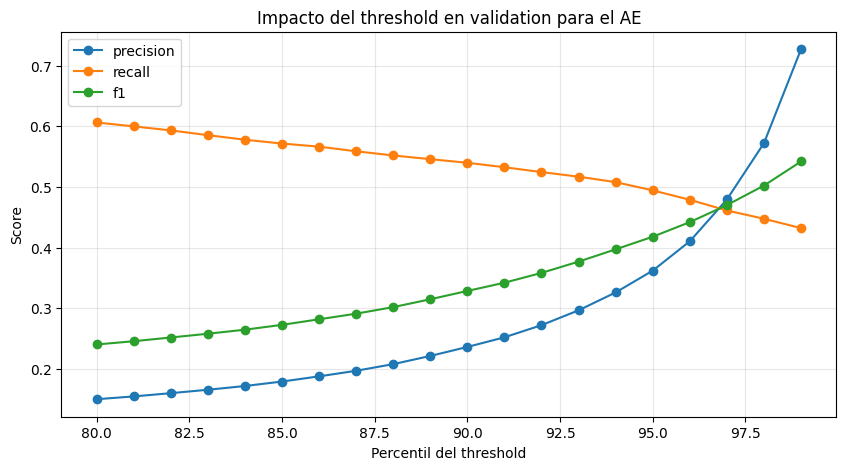

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="f1")

plt.xlabel("Percentil del threshold")
plt.ylabel("Score")
plt.title("Impacto del threshold en validation para el AE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Selección final del threshold del AE
# Percentil 98 como compromiso entre precision y recall

selected_row = threshold_df[threshold_df["percentile"] == 98].iloc[0]

selected_percentile = int(selected_row["percentile"])
selected_threshold = float(selected_row["threshold"])

print("Percentil seleccionado:", selected_percentile)
print("Threshold seleccionado:", selected_threshold)
print(selected_row)

Percentil seleccionado: 98
Threshold seleccionado: 0.0019514443162622944
percentile    98.000000
threshold      0.001951
precision      0.572337
recall         0.447458
f1             0.502251
Name: 18, dtype: float64


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_holdout = holdout_df["is_synthetic"].values

ae_tuned_pred = (ae_result["scores"] > selected_threshold).astype(int)

ae_tuned_metrics = {
    "precision": precision_score(y_holdout, ae_tuned_pred, zero_division=0),
    "recall": recall_score(y_holdout, ae_tuned_pred, zero_division=0),
    "f1": f1_score(y_holdout, ae_tuned_pred, zero_division=0),
    "threshold": selected_threshold,
    "threshold_percentile": selected_percentile
}

ae_tuned_metrics

{'precision': 0.5839134942971411,
 'recall': 0.44542372881355935,
 'f1': 0.5053522210114736,
 'threshold': 0.0019514443162622944,
 'threshold_percentile': 98}

### Evaluación AE

El rendimiento final del Autoencoder en holdout se calcula utilizando el umbral seleccionado previamente en validación. De este modo, se evita ajustar el criterio de decisión directamente sobre el conjunto de evaluación final y se obtiene una estimación más realista del comportamiento operativo del detector.

In [30]:
ae_comparison_df = pd.DataFrame([
    {
        "model": "AE_base",
        "selection": "fixed_percentile_95",
        **ae_result["metrics"]
    },
    {
        "model": "AE_tuned",
        "selection": f"validation_percentile_{selected_percentile}",
        **ae_tuned_metrics
    }
]).sort_values("f1", ascending=False).reset_index(drop=True)

ae_comparison_df

,model,selection,precision,recall,f1,threshold,threshold_percentile
0,AE_tuned,validation_percentile_98,0.583913,0.445424,0.505352,0.001951,98.0
1,AE_base,fixed_percentile_95,0.370108,0.495819,0.423839,0.000457,NaN


Aunque el entrenamiento del Autoencoder requiere varios minutos, este proceso se realiza offline.

En fase de despliegue, la inferencia consiste únicamente en un paso hacia adelante por la red, lo que permite obtener el error de reconstrucción en tiempo prácticamente constante, siendo adecuado para escenarios cercanos al tiempo real.

### Evaluación LOF

In [31]:

lof_result["metrics"]

{'precision': 0.3709400486478752,
 'recall': 0.5858757062146893,
 'f1': 0.454266690029788}

## Comparación

In [32]:
comparison_df = pd.DataFrame([
    {
        "model": "AE_tuned",
        "feature_set": "reduced",
        "selection": f"validation_percentile_{selected_percentile}",
        **ae_tuned_metrics
    },
    {
        "model": "LOF",
        "feature_set": "reduced",
        "selection": "default_internal",
        **lof_result["metrics"]
    }
]).sort_values(["f1", "precision", "recall"], ascending=False).reset_index(drop=True)

comparison_df

,model,feature_set,selection,precision,recall,f1,threshold,threshold_percentile
0,AE_tuned,reduced,validation_percentile_98,0.583913,0.445424,0.505352,0.001951,98.0
1,LOF,reduced,default_internal,0.370940,0.585876,0.454267,NaN,NaN


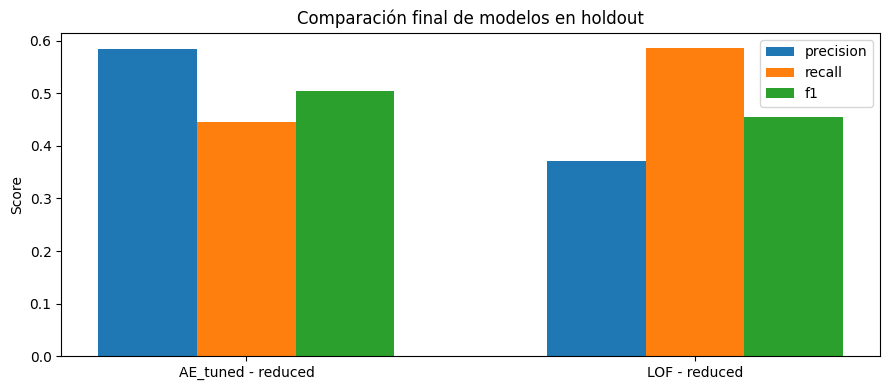

In [33]:
plot_df = comparison_df.copy()
plot_df["label"] = plot_df["model"] + " - " + plot_df["feature_set"]

metrics_to_plot = ["precision", "recall", "f1"]

x = np.arange(len(plot_df))
width = 0.22

plt.figure(figsize=(9, 4))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, plot_df[metric], width=width, label=metric)

plt.xticks(x + width, plot_df["label"])
plt.ylabel("Score")
plt.title("Comparación final de modelos en holdout")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
models_for_report = [
    ("AE_tuned", ae_tuned_pred),
    ("LOF", lof_result["preds"])
]

for name, preds in models_for_report:
    print(f"\n{name}")
    cm = confusion_matrix(y_holdout, preds)
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_holdout, preds, zero_division=0))


AE_tuned
Confusion matrix:
[[144730   2809]
 [  4908   3942]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97    147539
           1       0.58      0.45      0.51      8850

    accuracy                           0.95    156389
   macro avg       0.78      0.71      0.74    156389
weighted avg       0.95      0.95      0.95    156389


LOF
Confusion matrix:
[[138746   8793]
 [  3665   5185]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96    147539
           1       0.37      0.59      0.45      8850

    accuracy                           0.92    156389
   macro avg       0.67      0.76      0.71    156389
weighted avg       0.94      0.92      0.93    156389



AE → más conservador (menos falsos positivos)

LOF → más agresivo (detecta más anomalías)

Los resultados muestran que el Autoencoder ajustado presenta una mayor precisión y un mejor F1-score que LOF, lo que indica una mayor fiabilidad en la detección de anomalías. Sin embargo, LOF obtiene un mayor recall, siendo capaz de identificar un mayor número de anomalías a costa de un incremento significativo en falsos positivos.

Este comportamiento evidencia que ambos modelos presentan características complementarias: el Autoencoder actúa como un detector más conservador y preciso, mientras que LOF se comporta como un detector más sensible pero menos selectivo.

En consecuencia, estos resultados justifican la adopción de un enfoque híbrido en fases posteriores, donde se combine la robustez del Autoencoder con información adicional basada en reglas expertas del dominio marítimo.

In [35]:
selected_model_name = "AE"
selected_result_metrics = ae_tuned_metrics

print("Modelo seleccionado:", selected_model_name)
print("Métricas finales:", selected_result_metrics)

Modelo seleccionado: AE
Métricas finales: {'precision': 0.5839134942971411, 'recall': 0.44542372881355935, 'f1': 0.5053522210114736, 'threshold': 0.0019514443162622944, 'threshold_percentile': 98}


Aunque LOF presenta un mayor recall y AE una mayor precisión, ambos modelos obtienen un F1 similar.

Dado que en entornos operativos es importante controlar el número de falsos positivos, se selecciona el Autoencoder como modelo principal del pipeline.

LOF se conserva como modelo complementario debido a su mayor sensibilidad, siendo útil en etapas posteriores de análisis y scoring híbrido.

## Guardar resultados

In [36]:
holdout_results_df = holdout_df.copy()

holdout_results_df["ae_score"] = ae_result["scores"]
holdout_results_df["ae_pred_base"] = ae_result["preds"]
holdout_results_df["ae_pred_tuned"] = ae_tuned_pred

holdout_results_df["lof_score"] = lof_result["scores"]
holdout_results_df["lof_pred"] = lof_result["preds"]


holdout_results_df["final_score"] = holdout_results_df["ae_score"]
holdout_results_df["final_pred"] = holdout_results_df["ae_pred_tuned"]

holdout_results_df

,segment_id,MMSI,trajectory_id,speed_mean,speed_std,speed_max,delta_course_mean,delta_course_max,turning_rate_mean,turning_rate_max,acceleration_mean,acceleration_max,delta_t_mean,delta_t_max,distance_km,duration,ship_type,lat_mean,lon_mean,lat_start,lon_start,lat_end,lon_end,course_instability,speed_cv,turning_intensity,speed_variation,avg_speed_kmh,ais_gap,acceleration_instability,turning_ratio,slow_motion,high_speed_flag,low_distance_flag,points_density,erratic_motion_flag,stop_like_flag,is_synthetic,anomaly_type,ae_score,ae_pred_base,ae_pred_tuned,lof_score,lof_pred,final_score,final_pred
215589,1104147,368092380,0,0.000000,0.000000,0.000000,3.375000,4.9,0.018769,0.027222,0.000000e+00,0.000000,179.600000,181.0,0.007307,719.0,Special_Craft,47.647336,-122.343086,47.64735,-122.34307,47.64734,-122.34308,1.525000,0.000000,0.018792,0.000000,0.036584,1.007795,0.000000,1.450314,1,0,1,0.005568,0,1,0,normal,0.000023,0,0,-0.500837,0,0.000023,0
124152,662164,367388450,12,5.793333,0.540946,7.300000,27.021429,150.9,0.728779,5.203448,-1.510002e-03,0.033333,60.666667,71.0,53.338616,839.0,Special_Craft,29.999565,-90.451890,29.99868,-90.45915,30.01344,-90.47461,123.878571,0.093374,0.445408,1.506667,228.865547,1.170330,0.034843,7.139940,0,0,0,0.016484,0,0,0,normal,0.000059,0,0,-0.593676,0,0.000059,0
298910,1407683,370188000,0,14.520414,0.094682,14.681915,0.688889,2.6,0.006743,0.016250,-1.385614e-04,0.001429,89.000000,160.0,4.151796,810.0,Cargo,33.883212,-118.862401,33.87392,-118.84252,33.89218,-118.88175,1.911111,0.007956,0.007740,0.216676,18.452343,1.797753,0.001567,2.409705,0,1,0,0.011236,0,0,1,speed_anomaly,0.047995,1,1,-0.502415,0,0.047995,1
112165,591876,367183360,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,180.000000,183.0,0.004933,717.0,Special_Craft,47.573810,-122.345182,47.57382,-122.34518,47.57380,-122.34519,0.000000,0.000000,0.000000,0.000000,0.024769,1.016667,0.000000,0.000000,1,0,1,0.005556,0,1,0,normal,0.000020,0,0,-0.508543,0,0.000020,0
143079,752528,367505050,1,0.000000,0.000000,0.000000,41.510000,107.3,0.561883,1.532857,0.000000e+00,0.000000,76.454545,100.0,0.013653,770.0,Special_Craft,30.040345,-90.677228,30.04036,-90.67722,30.04035,-90.67722,65.790000,0.000000,0.542937,0.000000,0.063831,1.307967,0.000000,2.728066,1,0,1,0.013080,0,1,0,normal,0.000126,0,0,-0.580748,0,0.000126,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102491,541726,367100370,0,0.050000,0.050000,0.100000,94.890909,170.9,1.331493,2.407042,-1.279880e-04,0.001449,70.833333,81.0,0.009544,781.0,Service,38.782748,-75.120337,38.78276,-75.12034,38.78275,-75.12034,76.009091,0.999980,1.339636,0.050000,0.043994,1.143529,0.001577,1.807775,1,0,1,0.014118,0,1,0,normal,0.000251,0,0,-0.594304,0,0.000251,0
174847,910233,367672410,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,216.200000,360.0,0.005018,721.0,Special_Craft,48.125640,-123.454736,48.12564,-123.45473,48.12562,-123.45474,0.000000,0.000000,0.000000,0.000000,0.025057,1.665125,0.000000,0.000000,1,0,1,0.004625,0,1,0,normal,0.000033,0,0,-0.596674,0,0.000033,0
112757,593828,367187120,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,140.000000,401.0,0.014809,439.0,Service,26.771692,-80.053822,26.77171,-80.05385,26.77168,-80.05375,0.000000,0.000000,0.000000,0.000000,0.121438,2.864286,0.000000,0.000000,1,0,1,0.007143,0,0,0,normal,0.000154,0,0,-0.587957,0,0.000154,0
198387,1018128,367797070,0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000,180.200000,181.0,0.017388,721.0,Special_Craft,30.632342,-81.477430,30.63235,-81.47745,30.63234,-81.47743,0.000000,0.000000,0.000000,0.000000,0.086820,1.004440,0.000000,0.000000,1,0,1,0.005549,0,1,0,normal,0.000020,0,0,-0.622207,0,0.000020,0


ae_score: el score de anomalía del Autoencoder, que en vuestro caso es el error de reconstrucción

ae_pred: si AE marca ese segmento como anomalía o no

lof_score: el score de LOF

lof_pred: si LOF marca ese segmento como anomalía o no

final_score: el score del modelo principal elegido

final_pred: la predicción final del modelo principal

In [37]:
import json
import joblib
import os

model_selection_path = "/content/drive/MyDrive/TFG/results/model_selection/"
os.makedirs(model_selection_path, exist_ok=True)

comparison_df.to_csv(model_selection_path + "model_selection_summary.csv", index=False)
holdout_results_df.to_csv(model_selection_path + "holdout_with_predictions.csv", index=False)

metadata = {
    "selected_model": selected_model_name,
    "selected_variant": "AE_tuned",
    "feature_set": "reduced",
    "ae_base_metrics": ae_result["metrics"],
    "ae_tuned_metrics": ae_tuned_metrics,
    "ae_threshold_selection": {
        "selected_percentile": selected_percentile,
        "selected_threshold": selected_threshold,
        "selection_dataset": "validation"
    },
    "lof_metrics": lof_result["metrics"]
}

with open(model_selection_path + "selected_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Archivos guardados en:", model_selection_path)

Archivos guardados en: /content/drive/MyDrive/TFG/results/model_selection/


In [38]:
joblib.dump(ae_result["scaler"], model_selection_path + "ae_scaler.pkl")
joblib.dump(lof_result["scaler"], model_selection_path + "lof_scaler.pkl")
joblib.dump(lof_result["model"], model_selection_path + "lof_model.pkl")

ae_result["model"].save(model_selection_path + "selected_ae_model.keras")

print("Modelo AE y scalers guardados correctamente.")

Modelo AE y scalers guardados correctamente.
